In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=06327590aea228b5a6d8d862f50caf00df45f0ee9e37ae21e2ca99c21f74713a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {DEVICE}")

Kullanılan cihaz: cuda


In [3]:
# HAM10000 Kaggle'da bu yolda gelir
IMG_DIR_1 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
IMG_DIR_2 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
META_PATH = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'

df = pd.read_csv(META_PATH)
print(f"Toplam görüntü sayısı: {len(df)}")
print(f"\nSütunlar: {df.columns.tolist()}")
print(f"\nSınıf dağılımı:")
print(df['dx'].value_counts())

Toplam görüntü sayısı: 10015

Sütunlar: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Sınıf dağılımı:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


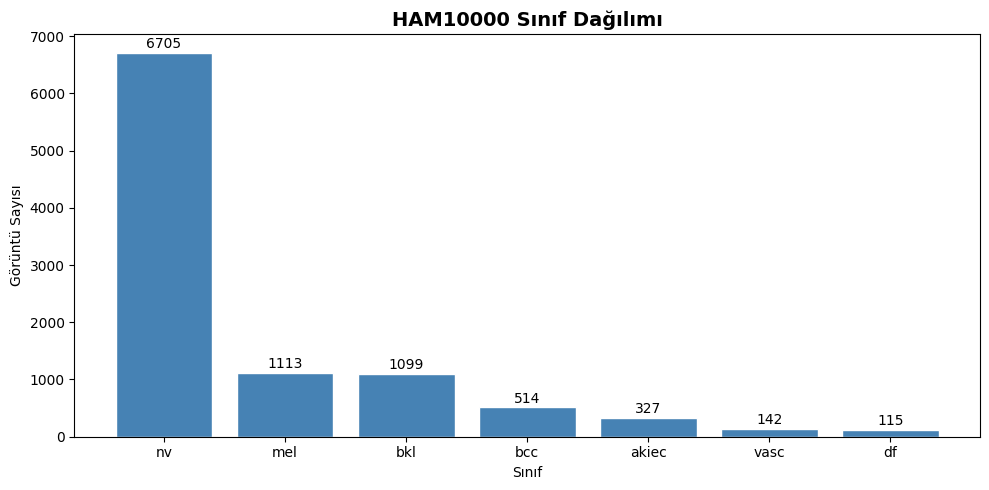


Sınıf dengesizliği var! nv sınıfı çok fazla — bunu ağırlıklı loss ile dengeleyeceğiz.


In [4]:
CLASS_NAMES = {
    'nv':    'Melanositik Nevus',
    'mel':   'Melanom',
    'bkl':   'Benign Keratoz',
    'bcc':   'Bazal Hücre Karsinomu',
    'akiec': 'Aktinik Keratoz',
    'vasc':  'Vasküler Lezyon',
    'df':    'Dermatofibrom'
}

counts = df['dx'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_title('HAM10000 Sınıf Dağılımı', fontsize=14, fontweight='bold')
ax.set_xlabel('Sınıf')
ax.set_ylabel('Görüntü Sayısı')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("\nSınıf dengesizliği var! nv sınıfı çok fazla — bunu ağırlıklı loss ile dengeleyeceğiz.")

In [5]:
# Her iki klasörden görüntü yollarını bul
def find_image_path(image_id):
    for folder in [IMG_DIR_1, IMG_DIR_2]:
        path = os.path.join(folder, image_id + '.jpg')
        if os.path.exists(path):
            return path
    return None

df['path'] = df['image_id'].apply(find_image_path)
df = df[df['path'].notna()].reset_index(drop=True)

# Sınıfları sayısal label'a çevir
label_list = sorted(df['dx'].unique())
label2idx = {label: idx for idx, label in enumerate(label_list)}
idx2label = {idx: label for label, idx in label2idx.items()}
df['label'] = df['dx'].map(label2idx)

print(f"Kullanılabilir görüntü sayısı: {len(df)}")
print(f"\nLabel mapping: {label2idx}")

Kullanılabilir görüntü sayısı: 10015

Label mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [6]:
# Önce %85 train+val, %15 test
train_val_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)

# Sonra train+val içinden %82 train, %18 val → toplamda ~%70/%15/%15
train_df, val_df = train_test_split(train_val_df, test_size=0.18, stratify=train_val_df['label'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6979 | Val: 1533 | Test: 1503


In [7]:
IMG_SIZE = 224  # EfficientNet-B4'ün standart giriş boyutu

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = np.array(Image.open(row['path']).convert('RGB'))
        label = row['label']
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label

train_dataset = HAMDataset(train_df, train_transform)
val_dataset   = HAMDataset(val_df,   val_transform)
test_dataset  = HAMDataset(test_df,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batch sayısı: {len(train_loader)}")

Train batch sayısı: 873


In [8]:
# Her sınıfın ağırlığı = toplam / (sınıf_sayısı * o_sınıftaki_örnek_sayısı)
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (len(label2idx) * class_counts),
    dtype=torch.float32
).to(DEVICE)

print("Sınıf ağırlıkları:")
for i, w in enumerate(class_weights):
    print(f"  {idx2label[i]:6s}: {w.item():.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

Sınıf ağırlıkları:
  akiec : 4.3728
  bcc   : 2.7849
  bkl   : 1.3016
  df    : 12.4625
  mel   : 1.2848
  nv    : 0.2134
  vasc  : 10.1735


In [9]:
def build_efficientnet_b4(num_classes=7, freeze=True):
    model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=num_classes)
    if freeze:
        for param in model.parameters():
            param.requires_grad = False
        # Sadece classifier katmanı açık
        for param in model.classifier.parameters():
            param.requires_grad = True
    return model.to(DEVICE)

def build_resnet50(num_classes=7):
    model = timm.create_model('resnet50', pretrained=True, num_classes=num_classes)
    return model.to(DEVICE)

effnet = build_efficientnet_b4(freeze=True)
print(f"EfficientNet-B4 yüklendi.")
print(f"Eğitilebilir parametre sayısı (Aşama 1): "
      f"{sum(p.numel() for p in effnet.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet-B4 yüklendi.
Eğitilebilir parametre sayısı (Aşama 1): 12,551


In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds      = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

def save_checkpoint(model, path):
    torch.save(model.state_dict(), path)
    print(f"Checkpoint kaydedildi: {path}")

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, save_path, history=None):
    if history is None:
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:02d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            save_checkpoint(model, save_path)

    print(f"\nEn iyi val accuracy: {best_val_acc:.4f}")
    return history

In [12]:
optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-3
)
scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_s1, patience=2, factor=0.5)

history = train_model(
    effnet, train_loader, val_loader, criterion,
    optimizer_s1, scheduler_s1,
    num_epochs=3,
    save_path='/kaggle/working/effnet_stage1.pt',
    history=None
)

Epoch 01/3 | Train Loss: 1.9041, Acc: 0.4291 | Val Loss: 1.6820, Acc: 0.5082
Checkpoint kaydedildi: /kaggle/working/effnet_stage1.pt
Epoch 02/3 | Train Loss: 1.6158, Acc: 0.5355 | Val Loss: 1.5440, Acc: 0.5316
Checkpoint kaydedildi: /kaggle/working/effnet_stage1.pt
Epoch 03/3 | Train Loss: 1.5050, Acc: 0.5786 | Val Loss: 1.5660, Acc: 0.5884
Checkpoint kaydedildi: /kaggle/working/effnet_stage1.pt

En iyi val accuracy: 0.5884


In [13]:
# EfficientNet-B4'ün son 2 block'unu aç
for name, param in effnet.named_parameters():
    if 'blocks.6' in name or 'blocks.5' in name or 'conv_head' in name or 'classifier' in name:
        param.requires_grad = True

print(f"Aşama 2 eğitilebilir parametre: "
      f"{sum(p.numel() for p in effnet.parameters() if p.requires_grad):,}")

optimizer_s2 = optim.Adam(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-4
)
scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_s2, patience=3, factor=0.5)

history = train_model(
    effnet, train_loader, val_loader, criterion,
    optimizer_s2, scheduler_s2,
    num_epochs=10,
    save_path='/kaggle/working/effnet_stage2.pt',
    history=history
)

Aşama 2 eğitilebilir parametre: 13,921,599
Epoch 01/10 | Train Loss: 1.3710, Acc: 0.5913 | Val Loss: 1.2172, Acc: 0.6425
Checkpoint kaydedildi: /kaggle/working/effnet_stage2.pt
Epoch 02/10 | Train Loss: 1.2379, Acc: 0.6338 | Val Loss: 1.0445, Acc: 0.6960
Checkpoint kaydedildi: /kaggle/working/effnet_stage2.pt
Epoch 03/10 | Train Loss: 1.1146, Acc: 0.6613 | Val Loss: 0.9749, Acc: 0.7071
Checkpoint kaydedildi: /kaggle/working/effnet_stage2.pt
Epoch 04/10 | Train Loss: 1.0305, Acc: 0.6901 | Val Loss: 0.8893, Acc: 0.7521
Checkpoint kaydedildi: /kaggle/working/effnet_stage2.pt
Epoch 05/10 | Train Loss: 0.9568, Acc: 0.7076 | Val Loss: 0.8487, Acc: 0.7547
Checkpoint kaydedildi: /kaggle/working/effnet_stage2.pt
Epoch 06/10 | Train Loss: 0.9335, Acc: 0.7041 | Val Loss: 0.8081, Acc: 0.7515
Epoch 07/10 | Train Loss: 0.9071, Acc: 0.7110 | Val Loss: 0.8481, Acc: 0.7639
Checkpoint kaydedildi: /kaggle/working/effnet_stage2.pt
Epoch 08/10 | Train Loss: 0.8497, Acc: 0.7319 | Val Loss: 0.7801, Acc: 0.76

In [14]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Tüm modeli açma, belleği patlatıyor.
# Sadece son bloklar + classifier eğitilecek.
for param in effnet.parameters():
    param.requires_grad = False

for name, param in effnet.named_parameters():
    if (
        'blocks.6' in name or
        'blocks.5' in name or
        'conv_head' in name or
        'bn2' in name or
        'classifier' in name
    ):
        param.requires_grad = True

print(f"Aşama 3 eğitilebilir parametre: "
      f"{sum(p.numel() for p in effnet.parameters() if p.requires_grad):,}")

optimizer_s3 = optim.Adam(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-5
)

scheduler_s3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s3,
    patience=3,
    factor=0.5
)

history = train_model(
    effnet,
    train_loader,
    val_loader,
    criterion,
    optimizer_s3,
    scheduler_s3,
    num_epochs=5,
    save_path='/kaggle/working/effnet_best.pt',
    history=history
)

Aşama 3 eğitilebilir parametre: 13,947,455
Epoch 01/5 | Train Loss: 0.7120, Acc: 0.7470 | Val Loss: 0.7739, Acc: 0.7886
Checkpoint kaydedildi: /kaggle/working/effnet_best.pt
Epoch 02/5 | Train Loss: 0.7048, Acc: 0.7634 | Val Loss: 0.7550, Acc: 0.7991
Checkpoint kaydedildi: /kaggle/working/effnet_best.pt
Epoch 03/5 | Train Loss: 0.6893, Acc: 0.7679 | Val Loss: 0.7540, Acc: 0.7841
Epoch 04/5 | Train Loss: 0.7049, Acc: 0.7716 | Val Loss: 0.7150, Acc: 0.7913
Epoch 05/5 | Train Loss: 0.6617, Acc: 0.7825 | Val Loss: 0.7428, Acc: 0.7841

En iyi val accuracy: 0.7991


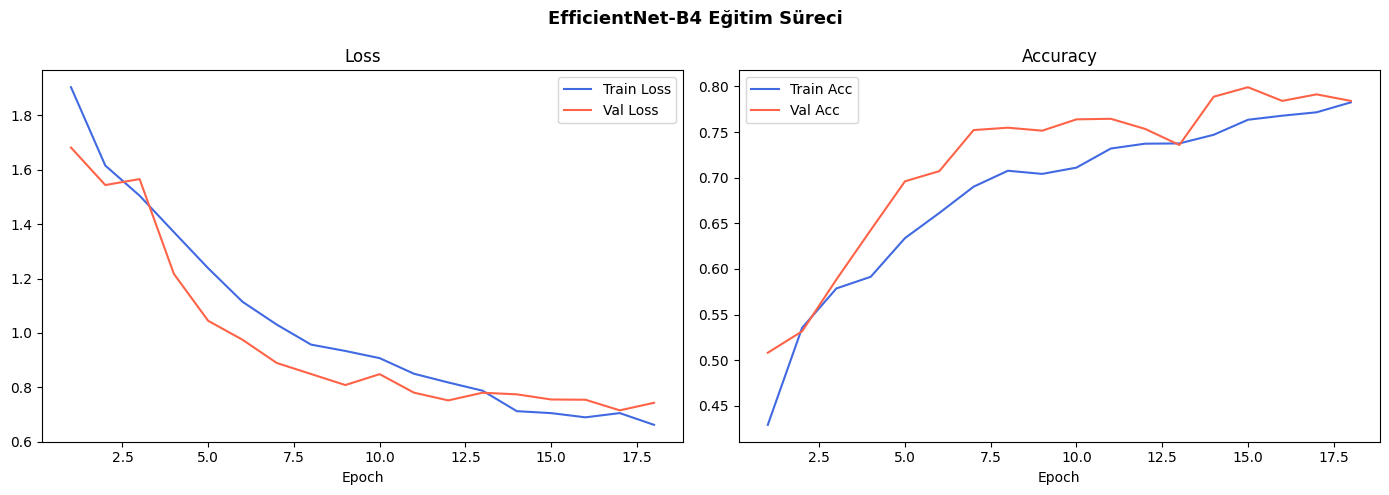

In [15]:
epochs = range(1, len(history['train_acc']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs, history['train_acc'], label='Train Acc', color='royalblue')
ax2.plot(epochs, history['val_acc'],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle('EfficientNet-B4 Eğitim Süreci', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
resnet = build_resnet50(num_classes=7)

optimizer_rn = optim.Adam(resnet.parameters(), lr=1e-4)
scheduler_rn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_rn, patience=3, factor=0.5)

history_rn = train_model(
    resnet, train_loader, val_loader, criterion,
    optimizer_rn, scheduler_rn,
    num_epochs=5,
    save_path='/kaggle/working/resnet50_best.pt',
    history=None
)

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 01/5 | Train Loss: 1.7299, Acc: 0.6293 | Val Loss: 1.4400, Acc: 0.6243
Checkpoint kaydedildi: /kaggle/working/resnet50_best.pt
Epoch 02/5 | Train Loss: 1.4526, Acc: 0.6295 | Val Loss: 1.1436, Acc: 0.7410
Checkpoint kaydedildi: /kaggle/working/resnet50_best.pt
Epoch 03/5 | Train Loss: 1.2423, Acc: 0.6531 | Val Loss: 0.9830, Acc: 0.7528
Checkpoint kaydedildi: /kaggle/working/resnet50_best.pt
Epoch 04/5 | Train Loss: 1.1666, Acc: 0.6594 | Val Loss: 0.9180, Acc: 0.7456
Epoch 05/5 | Train Loss: 1.1043, Acc: 0.6680 | Val Loss: 0.8888, Acc: 0.7528

En iyi val accuracy: 0.7528


In [17]:
# En iyi checkpoint'leri yükle
effnet.load_state_dict(torch.load('/kaggle/working/effnet_best.pt'))
resnet.load_state_dict(torch.load('/kaggle/working/resnet50_best.pt'))

_, eff_acc, eff_preds, eff_labels = evaluate(effnet, test_loader, criterion)
_, rn_acc,  rn_preds,  rn_labels  = evaluate(resnet, test_loader, criterion)

print("=" * 50)
print(f"EfficientNet-B4 Test Accuracy : {eff_acc:.4f} ({eff_acc*100:.2f}%)")
print(f"ResNet-50       Test Accuracy : {rn_acc:.4f}  ({rn_acc*100:.2f}%)")
print("=" * 50)

# Classification Report
class_name_list = [CLASS_NAMES[idx2label[i]] for i in range(7)]
print("\nEfficientNet-B4 Classification Report:")
print(classification_report(eff_labels, eff_preds, target_names=class_name_list))

EfficientNet-B4 Test Accuracy : 0.7651 (76.51%)
ResNet-50       Test Accuracy : 0.7385  (73.85%)

EfficientNet-B4 Classification Report:
                       precision    recall  f1-score   support

      Aktinik Keratoz       0.41      0.59      0.48        49
Bazal Hücre Karsinomu       0.65      0.81      0.72        77
       Benign Keratoz       0.61      0.61      0.61       165
        Dermatofibrom       0.46      0.76      0.58        17
              Melanom       0.43      0.55      0.48       167
    Melanositik Nevus       0.92      0.83      0.87      1006
      Vasküler Lezyon       0.72      0.82      0.77        22

             accuracy                           0.77      1503
            macro avg       0.60      0.71      0.64      1503
         weighted avg       0.79      0.77      0.78      1503



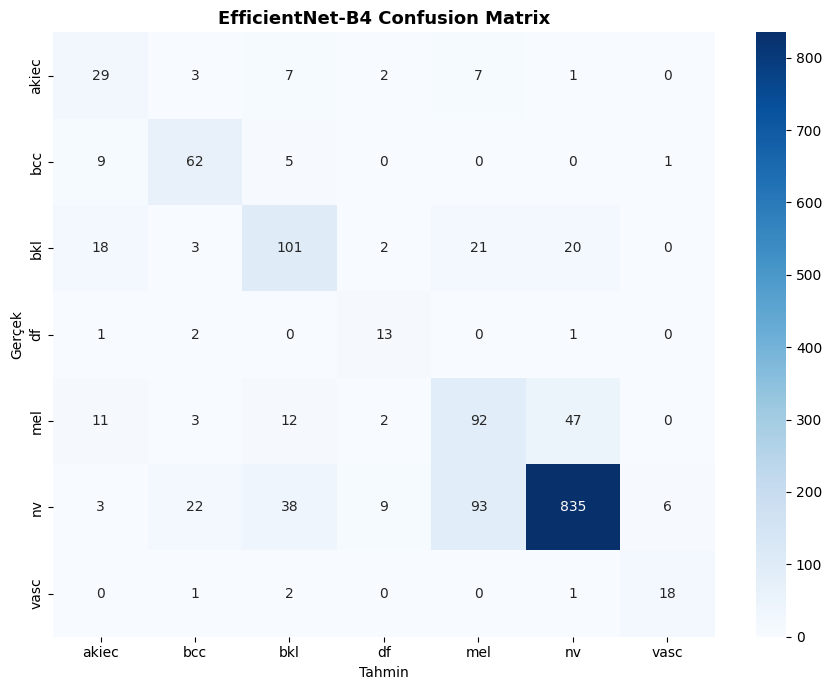

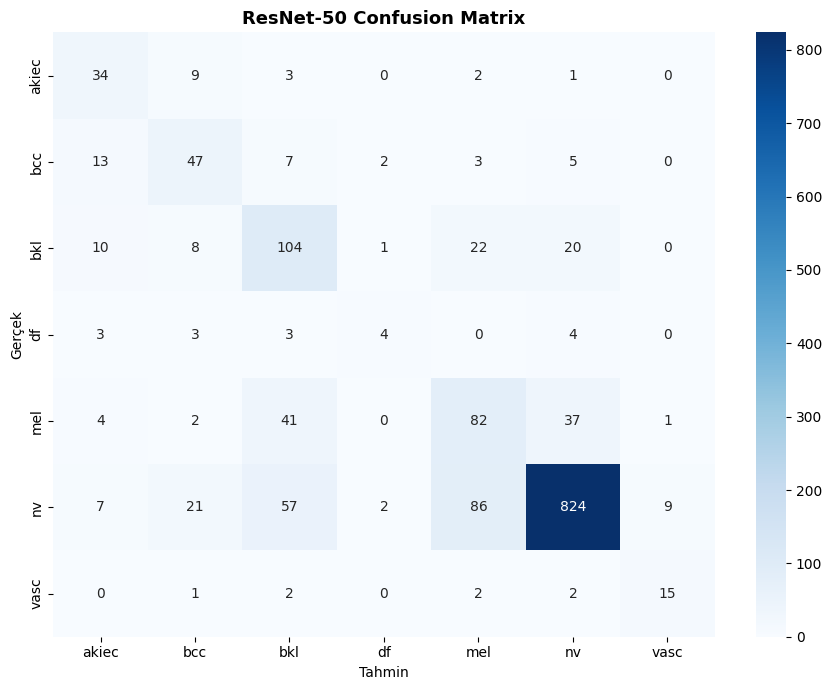

In [18]:
def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gerçek')
    plt.tight_layout()
    plt.show()

short_names = [idx2label[i] for i in range(7)]
plot_confusion_matrix(eff_labels, eff_preds, short_names, 'EfficientNet-B4 Confusion Matrix')
plot_confusion_matrix(rn_labels,  rn_preds,  short_names, 'ResNet-50 Confusion Matrix')

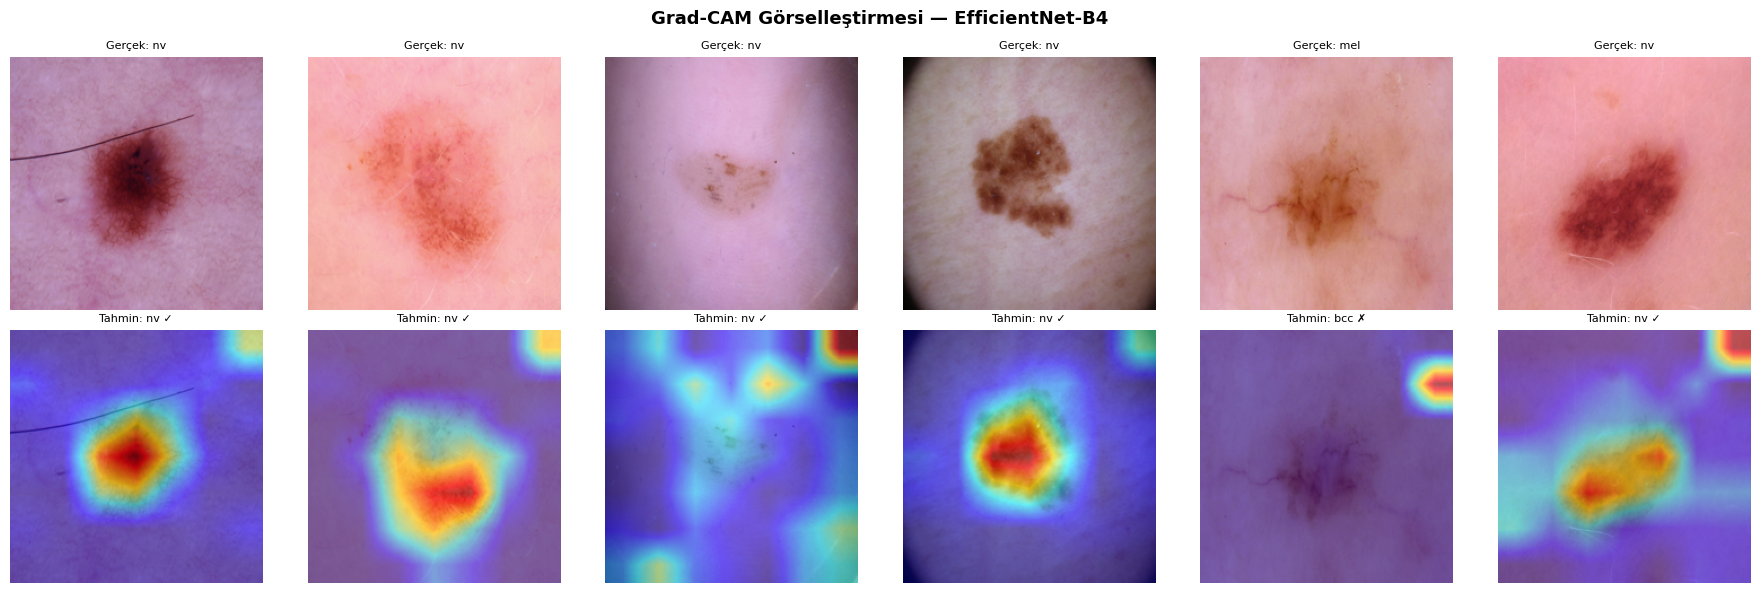

Üst satır: Orijinal görüntü | Alt satır: Grad-CAM ısı haritası (model neye baktı?)


In [19]:
# EfficientNet-B4'ün son conv katmanı hedef alınır
effnet.eval()
target_layers = [effnet.conv_head]
cam = GradCAM(model=effnet, target_layers=target_layers)

# Test setinden 6 örnek seç
sample_indices = list(range(6))
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Grad-CAM Görselleştirmesi — EfficientNet-B4', fontsize=13, fontweight='bold')

for col, idx in enumerate(sample_indices):
    row_data = test_df.iloc[idx]
    
    # Orijinal görüntü
    orig_img = np.array(Image.open(row_data['path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
    orig_normalized = orig_img.astype(np.float32) / 255.0
    
    # Transform uygulanmış tensor
    transformed = val_transform(image=np.array(Image.open(row_data['path']).convert('RGB')))
    input_tensor = transformed['image'].unsqueeze(0).to(DEVICE)
    
    true_label = idx2label[row_data['label']]
    targets    = [ClassifierOutputTarget(row_data['label'])]
    
    # Grad-CAM hesapla
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    cam_image     = show_cam_on_image(orig_normalized, grayscale_cam[0], use_rgb=True)
    
    # Tahmin
    with torch.no_grad():
        pred_idx = effnet(input_tensor).argmax(dim=1).item()
    pred_label = idx2label[pred_idx]
    
    # Orijinal görüntü
    axes[0][col].imshow(orig_img)
    axes[0][col].set_title(f"Gerçek: {true_label}", fontsize=8)
    axes[0][col].axis('off')
    
    # Grad-CAM görüntüsü
    correct = '✓' if pred_label == true_label else '✗'
    axes[1][col].imshow(cam_image)
    axes[1][col].set_title(f"Tahmin: {pred_label} {correct}", fontsize=8)
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()
print("Üst satır: Orijinal görüntü | Alt satır: Grad-CAM ısı haritası (model neye baktı?)")

In [20]:
results = {
    'EfficientNet-B4 Test Accuracy': f"{eff_acc*100:.2f}%",
    'ResNet-50 Test Accuracy':        f"{rn_acc*100:.2f}%",
    'Hipotez 2 Doğrulandı mı?':       'EVET' if eff_acc > rn_acc else 'HAYIR'
}

print("\n=== PROJE SONUÇLARI ===")
for k, v in results.items():
    print(f"{k}: {v}")

print("\nCheckpoint dosyaları:")
print(" - /kaggle/working/effnet_best.pt")
print(" - /kaggle/working/resnet50_best.pt")


=== PROJE SONUÇLARI ===
EfficientNet-B4 Test Accuracy: 76.51%
ResNet-50 Test Accuracy: 73.85%
Hipotez 2 Doğrulandı mı?: EVET

Checkpoint dosyaları:
 - /kaggle/working/effnet_best.pt
 - /kaggle/working/resnet50_best.pt
